# 全卷积网络

## 简介
Fully Convolutional Network (FCN) 主要用于图像分割。
- 没有全连接层
- 用 1x1 卷积调整通道
- 用转置卷积恢复高宽

## 架构
```mermaid
graph LR
    In(["图像<br>(3, 224, 224)"]) -->
    CNN(CNN) -->
    F(["特征图<br>(通道, 7, 7)"]) -->
    Conv1x1(1x1卷积) -->
    Deconv(转置卷积) -->
    Out(["分割图像<br>(类别, 224, 224)"])
```
最后用通道来承载类别概率，做到像素级分类，和 NIN、SSD 类似。

## 实现


In [1]:
%matplotlib inline
import torch
import torchvision
from torch import nn
from torch.nn import functional as F
from torchvision import models, transforms
import util

/root/autodl-tmp/envs/daily_learning/lib/python3.11/site-packages/requests/__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


使用 ResNet-18 做特征提取器


In [2]:
pretrained_net = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
list(pretrained_net.children())[-3:] # 看看最后三层

[Sequential(
   (0): BasicBlock(
     (conv1): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
     (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
     (relu): ReLU(inplace=True)
     (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
     (downsample): Sequential(
       (0): Conv2d(256, 512, kernel_size=(1, 1), stride=(2, 2), bias=False)
       (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
     )
   )
   (1): BasicBlock(
     (conv1): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
     (relu): ReLU(inplace=True)
     (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), 

去掉全连接层和平均池化层，承接输出为 512 通道的特征图


In [3]:
net = nn.Sequential(*list(pretrained_net.children())[:-2]) # 丢掉后两层

X = torch.rand(size=(1, 3, 320, 480))
net(X).shape

torch.Size([1, 512, 10, 15])

加入 1x1 卷积调整通道数为类别数


In [4]:
num_classes = 21 # VOC2012
net.add_module("conv1x1",
               nn.Conv2d(512, num_classes, kernel_size=1)) # 直接变 21 通道，减少计算量，因为后面 64x64 卷积计算量太大了
net.add_module("trans_conv",
               nn.ConvTranspose2d(num_classes,
                                  num_classes,
                                  kernel_size=64, # 配合 s = k/2 每次移半个窗口，有重叠度
                                  stride=32, # 放大 32 倍
                                  padding=16)) # k = 2p + s

用双线性插值，初始化转置卷积层


In [5]:
def bilinear_kernel(in_channels, out_channels, kernel_size):
    """双线性插值卷积核"""
    factor = (kernel_size + 1) // 2 # 卷积核中心点
    if kernel_size % 2 == 1:
        center = factor - 1 # 奇数卷积核中心点
    else:
        center = factor - 0.5 # 偶数卷积核中心点
    og = (torch.arange(kernel_size).reshape(-1, 1),
          torch.arange(kernel_size).reshape(1, -1)) # 卷积核坐标
    filt = (1 - torch.abs(og[0] - center) / factor) * \
           (1 - torch.abs(og[1] - center) / factor) # 双线性插值公式
    weight = torch.zeros((in_channels, out_channels, kernel_size, kernel_size)) # 全 0 卷积核
    weight[range(in_channels), range(out_channels), :, :] = filt # 把双线性插值卷积核放到对角线上
    return weight

一开始的效果就和双线性插值一样


原图 torch.Size([561, 728, 3])
上采样后 torch.Size([1122, 1456, 3])


array([<Axes: >, <Axes: >], dtype=object)

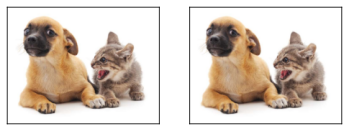

In [6]:
conv_trans = nn.ConvTranspose2d(3, 3, kernel_size=4, stride=2, padding=1, bias=False)
conv_trans.weight.data.copy_(bilinear_kernel(3, 3, 4))

img = transforms.ToTensor()(util.Image.open('./images/catdog.jpg')).unsqueeze(0)
up_img = conv_trans(img).squeeze().permute(1, 2, 0).detach()

util.set_figsize()
print("原图", img.squeeze().permute(1, 2, 0).shape)
print("上采样后", up_img.shape)
util.show_images([img.squeeze().permute(1, 2, 0), up_img], num_rows=1, num_cols=2, scale=3)

采用双线性插值，普通卷积层直接 xavier


In [7]:
W = bilinear_kernel(num_classes, num_classes, 64)
net.trans_conv.weight.data.copy_(W)

tensor([[[[0.0002, 0.0007, 0.0012,  ..., 0.0012, 0.0007, 0.0002],
          [0.0007, 0.0022, 0.0037,  ..., 0.0037, 0.0022, 0.0007],
          [0.0012, 0.0037, 0.0061,  ..., 0.0061, 0.0037, 0.0012],
          ...,
          [0.0012, 0.0037, 0.0061,  ..., 0.0061, 0.0037, 0.0012],
          [0.0007, 0.0022, 0.0037,  ..., 0.0037, 0.0022, 0.0007],
          [0.0002, 0.0007, 0.0012,  ..., 0.0012, 0.0007, 0.0002]],

         [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

         [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0

读取数据集


In [8]:
batch_size = 32
crop_size = (320, 480)
train_iter, test_iter = util.data.load_data_voc(batch_size, crop_size)

read 1114 examples
read 1078 examples


训练


loss 0.213, train acc 0.925, test acc 0.848
554.6 examples/sec on [device(type='cuda', index=0)]


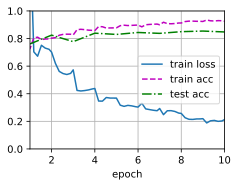

In [9]:
def loss(inputs, targets):
    return F.cross_entropy(inputs, targets, reduction='none').mean(dim=(1, 2)) # 对每个像素点求交叉熵，然后对每张图求平均

num_epochs = 10
lr = 5e-3
wd = 1e-4
devices = util.try_all_gpus()
trainer = torch.optim.SGD(net.parameters(), lr=lr, weight_decay=wd)
util.train.train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs, devices)

预测


In [10]:
def predict(img, net):
    """预测"""
    net.eval()
    with torch.no_grad():
        X = test_iter.dataset.normalize_image(img).unsqueeze(0) # 标准化并增加 batch 维度
        return net(X.to(devices[0])).argmax(dim=1).squeeze() # 预测类别

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
      dtype=object)

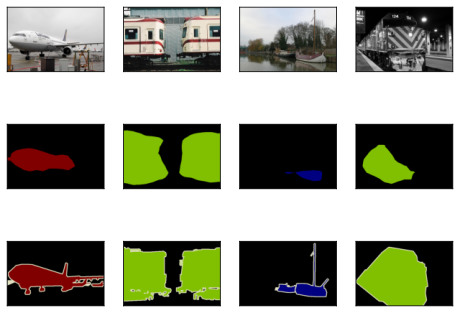

In [11]:
def label2image(pred):
    """将预测类别转为彩色图像"""
    colormap = torch.tensor(util.data.VOC_COLORMAP, device=devices[0])
    return colormap[pred.long(), :]

voc_dir = util.data.download_extract('voc2012', 'VOCdevkit/VOC2012')
test_images, test_labels = util.data.read_voc_images(voc_dir, False)
n, imgs = 4, []
for i in range(n):
    crop_rect = (0, 0, 320, 480)
    X = transforms.functional.crop(test_images[i], *crop_rect)
    pres = label2image(predict(X, net))
    imgs += [X.permute(1, 2, 0),
             pres.cpu(),
             transforms.functional.crop(test_labels[i], *crop_rect).permute(1, 2, 0)]
util.show_images(imgs[::3] + imgs[1::3] + imgs[2::3], 3, n, scale=2)